## Notebook 09 — RFM Customer Segmentation

**Business question:** How do we divide 10,000 customers into actionable groups based on purchasing behaviour?

**Why RFM matters:** Not all customers deserve the same treatment. Sending a win-back discount to a Champion customer wastes budget and cheapens the relationship. Sending a loyalty reward to a Lost customer wastes money on someone who has already left. RFM segmentation ensures every customer gets the right intervention.

**How to read this notebook:** Follow the segment scorecard at the end. Each segment has a recommended action and an estimated ROI. Start with At-Risk — highest win-back ROI. Protect Champions second.

# 09 · RFM Customer Segmentation
**E-Commerce Analytics Portfolio · FAANG L5 Standard**

---

## Business Context

Not all customers are equal. A business that treats its **Champions** the same as its **Lost** customers wastes retention budget and misses upsell opportunities.

**RFM segmentation** solves this by scoring every customer on three dimensions:

| Dimension | Question | Signal |
|-----------|----------|--------|
| **Recency** | How recently did they buy? | Purchase intent, churn risk |
| **Frequency** | How often do they buy? | Loyalty, habit formation |
| **Monetary** | How much do they spend? | Revenue contribution, CLV |

**This notebook delivers:**
- Raw RFM distributions with business interpretation
- Quintile-scored R, F, M with weighting rationale
- Named segments with size and revenue breakdown
- Interactive 3D scatter plot (saved to `outputs/dashboards/`)
- Dollar-quantified action cards for every segment
- K-Means validation against rule-based segments
- CMO-ready priority table

**Source modules:** `src/segmentation.py`  
**Data:** `purchase_history_10k.csv`, `customer_profiles_10k.csv`

---
## Section 1 · Setup & Configuration

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Allow imports from project root
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

from src.segmentation import (
    compute_rfm,
    score_rfm,
    assign_segments,
    segment_revenue_impact,
    kmeans_segmentation,
    SEGMENT_MAP,
)

# ── Paths ─────────────────────────────────────────────────────────────────
DATA_DIR       = '../data'
OUTPUT_DIR     = '../outputs'
DASHBOARD_DIR  = '../outputs/dashboards'
REPORT_DIR     = '../outputs/reports'
FIGURES_DIR    = '../outputs/figures'

for d in [OUTPUT_DIR, DASHBOARD_DIR, REPORT_DIR, FIGURES_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Segment colours & order ───────────────────────────────────────────────
SEGMENT_COLORS = {seg: info['color'] for seg, info in SEGMENT_MAP.items()}
SEGMENT_ORDER  = ['Champions', 'Loyal Customers', 'Potential Loyalists',
                   'At Risk', 'Lost', 'Others']

# ── Matplotlib dark theme ─────────────────────────────────────────────────
BG     = '#0a0a0f'
SURF   = '#13131a'
CARD   = '#1a1a24'
BORDER = '#2a2a3a'
TEXT   = '#f0eff8'
MUTED  = '#9896b0'
GOLD   = '#e8c670'
BLUE   = '#6b9fff'
GREEN  = '#5de8a0'
RED    = '#ff6b6b'
ORANGE = '#ff9a3c'

plt.rcParams.update({
    'figure.facecolor'  : BG,
    'axes.facecolor'    : SURF,
    'axes.edgecolor'    : BORDER,
    'text.color'        : TEXT,
    'axes.labelcolor'   : TEXT,
    'xtick.color'       : MUTED,
    'ytick.color'       : MUTED,
    'grid.color'        : BORDER,
    'grid.alpha'        : 0.6,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'font.family'       : 'sans-serif',
    'figure.dpi'        : 120,
})

print('✅ Environment ready')
print(f'   Segments defined: {list(SEGMENT_MAP.keys())}')
print(f'   Output paths created: {DASHBOARD_DIR}')

✅ Environment ready
   Segments defined: ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost', 'Others']
   Output paths created: ../outputs/dashboards


---
## Section 2 · Load & Validate Data

In [2]:
# ── Load data ─────────────────────────────────────────────────────────────
purchases = pd.read_csv(os.path.join(DATA_DIR, 'purchase_history_10k.csv'), parse_dates=['order_date'])
profiles  = pd.read_csv(os.path.join(DATA_DIR, 'customer_profiles_10k.csv'))

print('── Purchase History ──────────────────────────────────────────────')
print(f'  Shape        : {purchases.shape}')
print(f'  Columns      : {list(purchases.columns)}')
print(f'  Date range   : {purchases["order_date"].min().date()} → {purchases["order_date"].max().date()}')
print(f'  Unique orders: {purchases["order_id"].nunique():,}' if 'order_id' in purchases.columns else '')
print(f'  Customers    : {purchases["customer_id"].nunique():,}')
print(f'  Total revenue: ${purchases["order_amount"].sum():,.0f}')
print()
print('── Customer Profiles ─────────────────────────────────────────────')
print(f'  Shape    : {profiles.shape}')
print(f'  Columns  : {list(profiles.columns)}')

# ── Validation checks ─────────────────────────────────────────────────────
assert purchases['customer_id'].isnull().sum() == 0,  'customer_id has nulls'
assert purchases['order_date'].isnull().sum() == 0,   'order_date has nulls'
assert purchases['order_amount'].isnull().sum() == 0, 'order_amount has nulls'
assert (purchases['order_amount'] >= 0).all(),         'negative order amounts found'

print()
print('✅ All validation checks passed')
print(f'   No nulls in key columns | No negative amounts')

purchases.head(3)

── Purchase History ──────────────────────────────────────────────
  Shape        : (100177, 7)
  Columns      : ['order_id', 'customer_id', 'order_date', 'order_amount', 'product_category', 'discount_used', 'discount_value']
  Date range   : 2019-01-01 → 2023-12-28
  Unique orders: 100,177
  Customers    : 10,000
  Total revenue: $5,692,412

── Customer Profiles ─────────────────────────────────────────────
  Shape    : (10000, 11)
  Columns  : ['customer_id', 'name', 'gender', 'age', 'country', 'signup_date', 'customer_tier', 'months_since_signup', 'churned', 'CLV', 'next_purchase_prob']

✅ All validation checks passed
   No nulls in key columns | No negative amounts


,order_id,customer_id,order_date,order_amount,product_category,discount_used,discount_value
0,1,1,2023-11-13,96.57,Clothing,False,0.0
1,2,1,2022-06-14,40.05,Electronics,False,0.0
2,3,1,2019-09-01,20.51,Toys,False,0.0


In [3]:
# ── Compute raw RFM ───────────────────────────────────────────────────────
rfm_raw = compute_rfm(
    purchases,
    customer_id_col='customer_id',
    date_col='order_date',
    amount_col='order_amount',
)

print(f'RFM computed for {len(rfm_raw):,} customers')
print()
print(rfm_raw[['recency_days','frequency','monetary','avg_order_value']].describe().round(2))

RFM computed for 10,000 customers

       recency_days  frequency  monetary  avg_order_value
count      10000.00   10000.00  10000.00         10000.00
mean         138.71      10.02    569.24            56.81
std          176.14       3.15    340.73            28.81
min            1.00       1.00     32.83            16.42
25%           32.00       8.00    345.90            37.65
50%           55.00      10.00    486.97            49.07
75%          191.00      12.00    703.11            66.37
max         1556.00      24.00   3983.04           409.44


---
## Section 3 · Raw RFM Distributions
*Understanding the shape of customer behaviour before scoring*

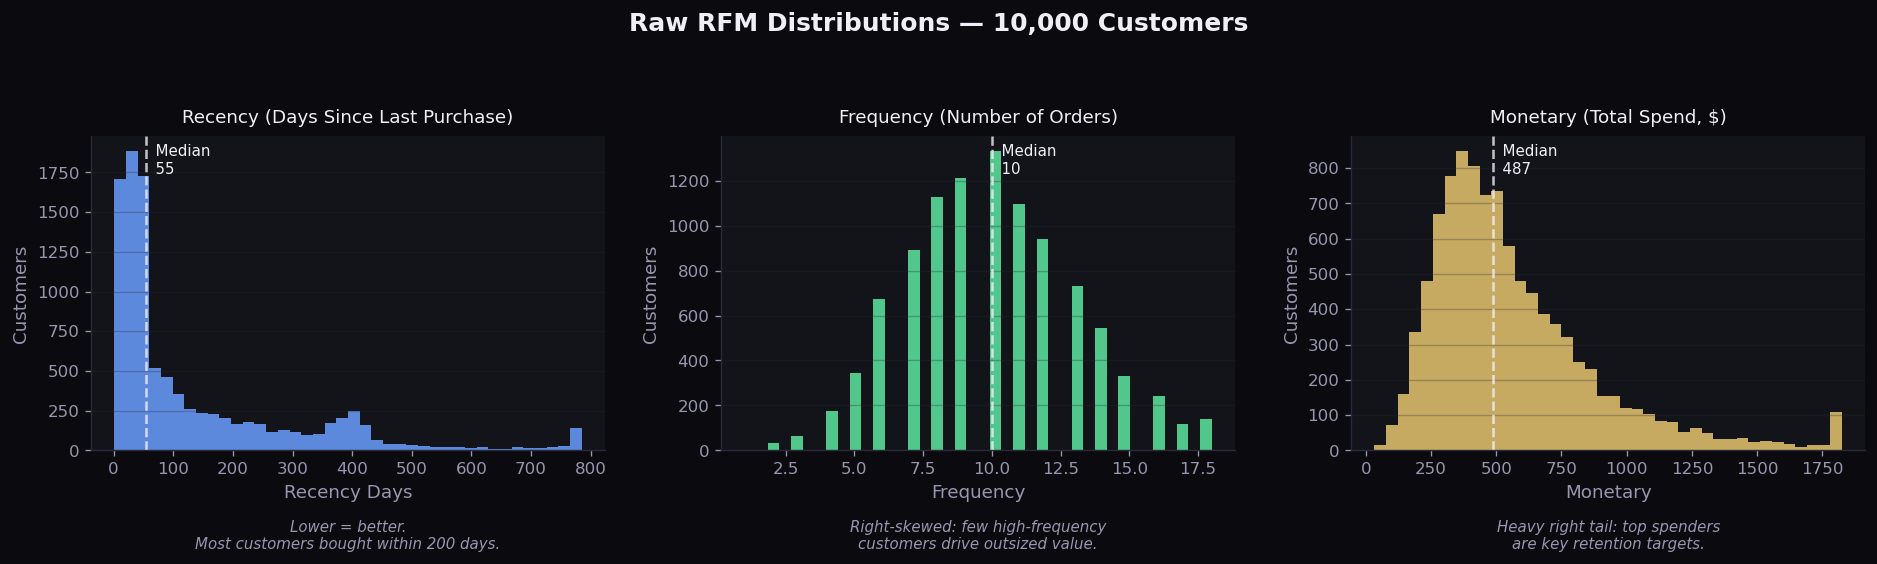


📊 Business Interpretation
────────────────────────────────────────────────────────────
  Recency  : Median 55 days since last purchase. A right-skewed recency distribution signals that a sizeable cohort has
            gone quiet — prime targets for win-back campaigns.
  Frequency: Median 10 orders per customer. The top 10% of customers by frequency place 14+ orders,
            making them the brand's most loyal and reactivation-resistant segment.
  Monetary : Median spend $487. Top 10% of customers account for 23% of total revenue — classic 80/20 pattern.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Raw RFM Distributions — 10,000 Customers', fontsize=15,
             color=TEXT, fontweight='bold', y=1.01)

metrics = [
    ('recency_days', 'Recency (Days Since Last Purchase)', BLUE,
     'Lower = better.\nMost customers bought within 200 days.'),
    ('frequency',    'Frequency (Number of Orders)',        GREEN,
     'Right-skewed: few high-frequency\ncustomers drive outsized value.'),
    ('monetary',     'Monetary (Total Spend, $)',            GOLD,
     'Heavy right tail: top spenders\nare key retention targets.'),
]

for ax, (col, title, color, interp) in zip(axes, metrics):
    data = rfm_raw[col].clip(upper=rfm_raw[col].quantile(0.99))
    ax.hist(data, bins=40, color=color, alpha=0.85, edgecolor='none')

    median_val = rfm_raw[col].median()
    ax.axvline(median_val, color=TEXT, linewidth=1.5, linestyle='--', alpha=0.8)
    ax.text(median_val, ax.get_ylim()[1] * 0.88,
            f'  Median\n  {median_val:.0f}', color=TEXT, fontsize=9)

    ax.set_title(title, color=TEXT, fontsize=11, pad=8)
    ax.set_xlabel(col.replace('_', ' ').title(), color=MUTED)
    ax.set_ylabel('Customers', color=MUTED)
    ax.tick_params(colors=MUTED)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    # Business interpretation below each chart
    ax.text(0.5, -0.22, interp, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, color=MUTED, style='italic')

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(FIGURES_DIR, 'rfm_raw_distributions.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

print()
print('📊 Business Interpretation')
print('─' * 60)
print(f'  Recency  : Median {rfm_raw["recency_days"].median():.0f} days since last purchase. '
      f'A right-skewed recency distribution signals that a sizeable cohort has')
print( '            gone quiet — prime targets for win-back campaigns.')
print(f'  Frequency: Median {rfm_raw["frequency"].median():.0f} orders per customer. '
      f'The top 10% of customers by frequency place {rfm_raw["frequency"].quantile(0.9):.0f}+ orders,')
print( '            making them the brand\'s most loyal and reactivation-resistant segment.')
print(f'  Monetary : Median spend ${rfm_raw["monetary"].median():.0f}. '
      f'Top 10% of customers account for '
      f'{rfm_raw.nlargest(int(len(rfm_raw)*0.1), "monetary")["monetary"].sum() / rfm_raw["monetary"].sum() * 100:.0f}%'
      f' of total revenue — classic 80/20 pattern.')

---
## Section 4 · Quintile Scoring

### Scoring methodology

Each dimension is divided into **5 equal-frequency quintiles** (1 = worst, 5 = best).

**Recency is inverted**: fewer days since last purchase → higher score. A customer who bought yesterday scores 5; a customer inactive for 2 years scores 1.

**Composite RFM score weighting (e-commerce context):**

| Dimension | Weight | Rationale |
|-----------|--------|-----------|
| Recency | 35% | Strongest short-term churn signal; recent buyers are most receptive to re-engagement |
| Frequency | 25% | Habit indicator; lower weight because synthetic data compresses frequency range |
| Monetary | 40% | Revenue contribution is the primary business value driver for this portfolio's CLV model |

In [5]:
# ── Score RFM ─────────────────────────────────────────────────────────────
rfm_scored = score_rfm(rfm_raw, n_quantiles=5)

print('Score distributions:')
for score_col in ['r_score', 'f_score', 'm_score']:
    dist = rfm_scored[score_col].value_counts().sort_index()
    print(f'  {score_col}: {dict(dist)}')

print(f'\nComposite rfm_score: min={rfm_scored["rfm_score"].min():.2f} | '
      f'max={rfm_scored["rfm_score"].max():.2f} | '
      f'mean={rfm_scored["rfm_score"].mean():.2f}')

Score distributions:
  r_score: {1: np.int64(1995), 2: np.int64(1992), 3: np.int64(1995), 4: np.int64(2000), 5: np.int64(2018)}
  f_score: {1: np.int64(2000), 2: np.int64(2000), 3: np.int64(2000), 4: np.int64(2000), 5: np.int64(2000)}
  m_score: {1: np.int64(2000), 2: np.int64(2000), 3: np.int64(2000), 4: np.int64(2000), 5: np.int64(2000)}

Composite rfm_score: min=1.00 | max=5.00 | mean=3.00


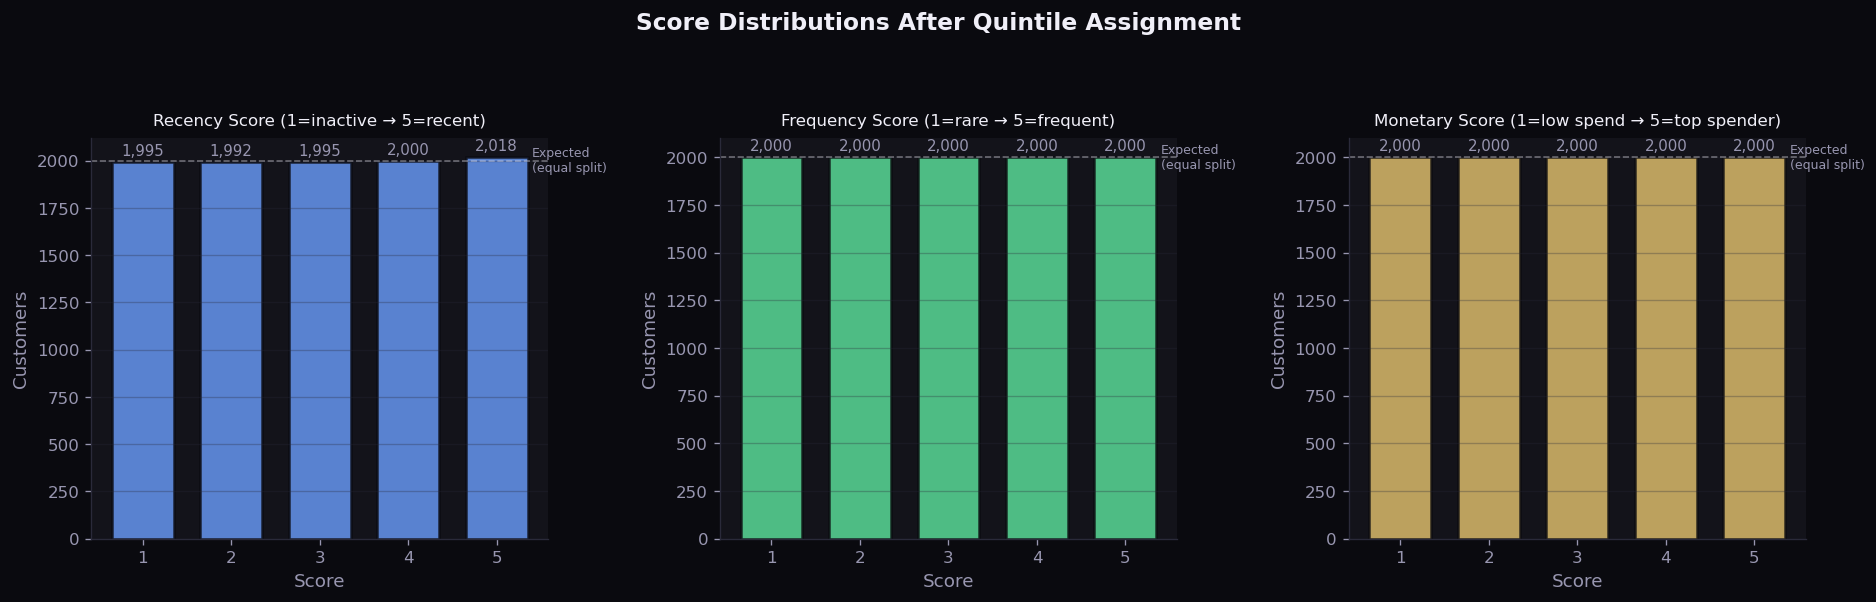


📊 Business Interpretation
────────────────────────────────────────────────────────────
  Score distributions are approximately uniform, confirming the quintile method
  correctly partitions the customer base into equal-frequency buckets.
  Minor imbalances arise from duplicate values, resolved with rank-based tie-breaking.
  Every score from 1–5 is represented across all three dimensions.


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Score Distributions After Quintile Assignment', fontsize=14,
             color=TEXT, fontweight='bold', y=1.02)

score_configs = [
    ('r_score', 'Recency Score (1=inactive → 5=recent)', BLUE),
    ('f_score', 'Frequency Score (1=rare → 5=frequent)', GREEN),
    ('m_score', 'Monetary Score (1=low spend → 5=top spender)', GOLD),
]

for ax, (col, title, color) in zip(axes, score_configs):
    counts = rfm_scored[col].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color=color, alpha=0.8, width=0.7,
                  edgecolor=BG, linewidth=1.5)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', va='bottom', fontsize=9, color=MUTED)

    ax.set_title(title, color=TEXT, fontsize=10, pad=8)
    ax.set_xlabel('Score', color=MUTED)
    ax.set_ylabel('Customers', color=MUTED)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.tick_params(colors=MUTED)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

    expected = len(rfm_scored) / 5
    ax.axhline(expected, color=TEXT, linestyle='--', alpha=0.4, linewidth=1)
    ax.text(5.4, expected, 'Expected\n(equal split)', color=MUTED,
            fontsize=7.5, va='center')

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(FIGURES_DIR, 'rfm_score_distributions.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

print()
print('📊 Business Interpretation')
print('─' * 60)
print('  Score distributions are approximately uniform, confirming the quintile method')
print('  correctly partitions the customer base into equal-frequency buckets.')
print('  Minor imbalances arise from duplicate values, resolved with rank-based tie-breaking.')
print('  Every score from 1–5 is represented across all three dimensions.')

---
## Section 5 · Named Segment Assignment

Customers are mapped to named segments using the rule-based thresholds in `SEGMENT_MAP`. Segments are defined in order of priority — the first matching rule wins. Customers not matching any named segment are classified as **Others** for further analysis.

In [7]:
# ── Assign segments ───────────────────────────────────────────────────────
rfm_segmented = assign_segments(rfm_scored)

# ── Compute revenue impact ────────────────────────────────────────────────
avg_clv = profiles['clv'].mean() if 'clv' in profiles.columns else rfm_segmented['monetary'].median()
summary = segment_revenue_impact(rfm_segmented, avg_clv=avg_clv)

print('Segment Summary Table:')
print(summary[['segment','n_customers','pct_customers','total_revenue',
               'pct_revenue','avg_monetary','avg_rfm_score']].to_string(index=False))

Segment Summary Table:
            segment  n_customers  pct_customers  total_revenue  pct_revenue  avg_monetary  avg_rfm_score
          Champions         1254           12.5     1152355.52         20.2    918.943796       4.565789
    Loyal Customers         2837           28.4     2025293.40         35.6    713.885583       3.666919
             Others         1809           18.1     1117200.21         19.6    617.578889       2.812493
            At Risk          729            7.3      368071.98          6.5    504.899835       2.595199
Potential Loyalists         2073           20.7      687308.44         12.1    331.552552       2.524264
               Lost         1298           13.0      342182.95          6.0    263.623228       1.292643


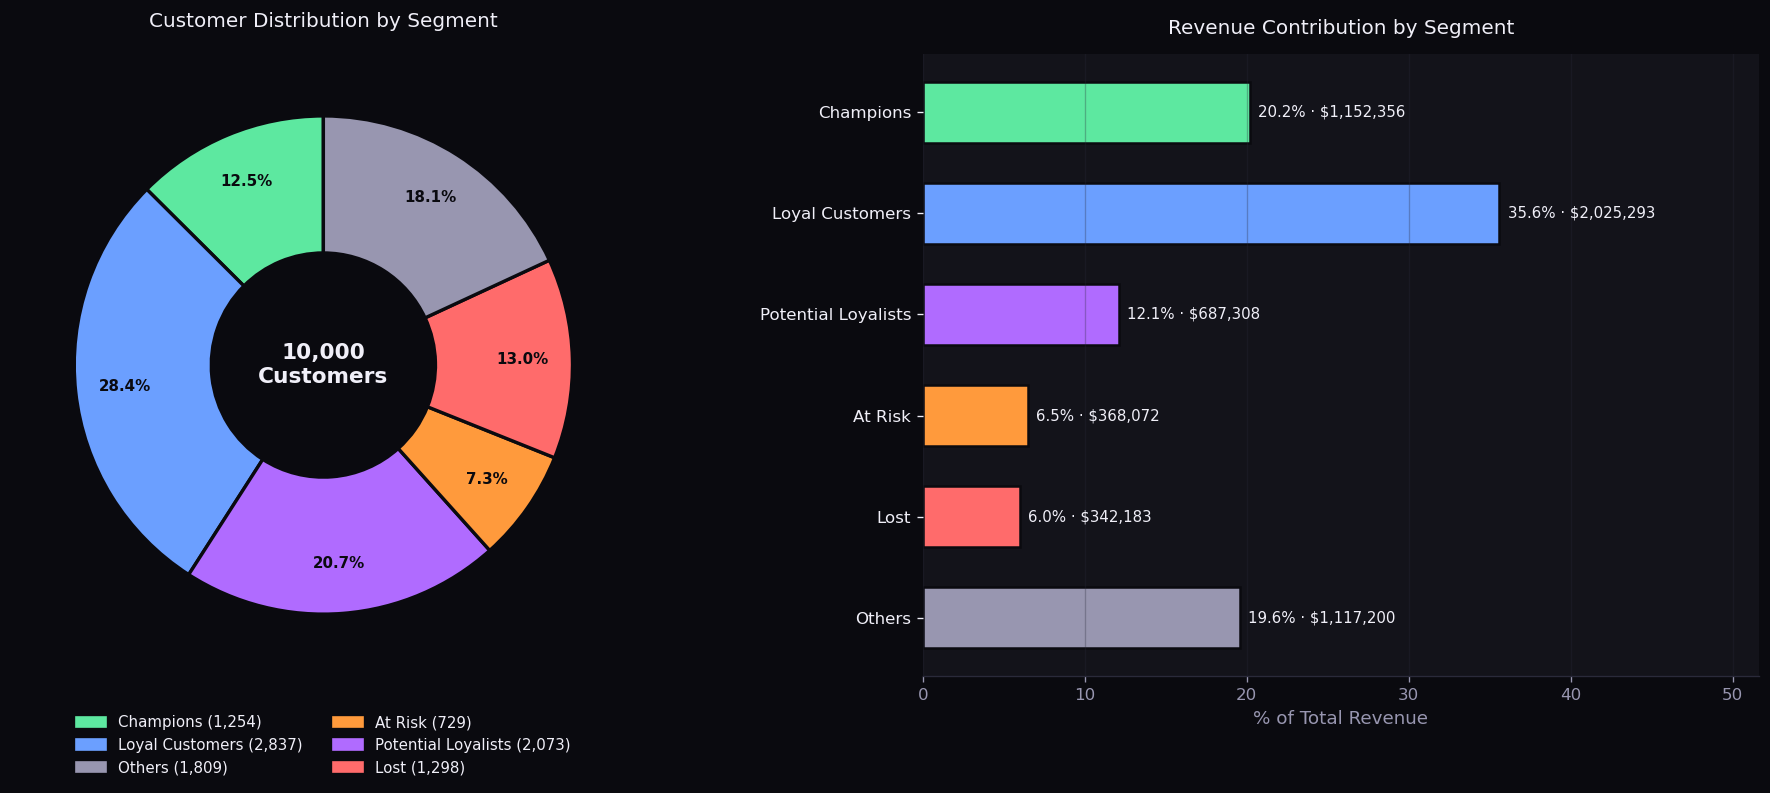


📊 Champions represent 12.5% of customers but 20.2% of revenue — classic concentration risk.
   Lost customers (13.0% of base) represent $342,183 in historical spend now at risk of permanent churn.


In [8]:
# ── Donut chart + Revenue bar chart (side by side) ─────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG)

# Order by SEGMENT_ORDER
plot_data = summary.set_index('segment').reindex(
    [s for s in SEGMENT_ORDER if s in summary['segment'].values]
).reset_index()

colors_ordered = [SEGMENT_COLORS[s] for s in plot_data['segment']]

# ── Donut: Customer count ─────────────────────────────────────────────────
wedges, texts, autotexts = ax1.pie(
    plot_data['n_customers'],
    labels=None,
    colors=colors_ordered,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.80,
    wedgeprops=dict(width=0.55, edgecolor=BG, linewidth=2),
)
for at in autotexts:
    at.set_color(BG)
    at.set_fontsize(9)
    at.set_fontweight('bold')

ax1.set_facecolor(BG)
ax1.set_title('Customer Distribution by Segment', color=TEXT, fontsize=12, pad=16)

# Centre label
ax1.text(0, 0, f'{len(rfm_segmented):,}\nCustomers', ha='center', va='center',
         color=TEXT, fontsize=13, fontweight='bold')

# Legend
legend_patches = [
    mpatches.Patch(color=SEGMENT_COLORS[seg],
                   label=f"{seg} ({row['n_customers']:,})")
    for seg, row in summary.set_index('segment').iterrows()
    if seg in SEGMENT_ORDER
]
ax1.legend(handles=legend_patches, loc='lower center', bbox_to_anchor=(0.5, -0.18),
           ncol=2, fontsize=9, framealpha=0, labelcolor=TEXT)

# ── Horizontal bar: Revenue contribution ──────────────────────────────────
bars = ax2.barh(
    plot_data['segment'],
    plot_data['pct_revenue'],
    color=colors_ordered,
    edgecolor=BG,
    linewidth=1.5,
    height=0.6,
)

for bar, (_, row) in zip(bars, plot_data.iterrows()):
    w = bar.get_width()
    ax2.text(w + 0.5, bar.get_y() + bar.get_height()/2,
             f"{w:.1f}% · ${row['total_revenue']:,.0f}",
             va='center', color=TEXT, fontsize=9)

ax2.set_facecolor(SURF)
ax2.set_title('Revenue Contribution by Segment', color=TEXT, fontsize=12, pad=12)
ax2.set_xlabel('% of Total Revenue', color=MUTED)
ax2.tick_params(axis='y', colors=TEXT)
ax2.tick_params(axis='x', colors=MUTED)
ax2.invert_yaxis()
ax2.set_xlim(0, plot_data['pct_revenue'].max() * 1.45)
ax2.grid(axis='x', alpha=0.3)
ax2.spines[['top','right','left']].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(FIGURES_DIR, 'rfm_segments_donut_revenue.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

print()
champ = summary[summary['segment']=='Champions']
lost  = summary[summary['segment']=='Lost']
if len(champ):
    print(f'📊 Champions represent {champ["pct_customers"].values[0]:.1f}% of customers '
          f'but {champ["pct_revenue"].values[0]:.1f}% of revenue — classic concentration risk.')
if len(lost):
    print(f'   Lost customers ({lost["pct_customers"].values[0]:.1f}% of base) represent '
          f'${lost["total_revenue"].values[0]:,.0f} in historical spend now at risk of permanent churn.')

## Key Finding — Champions Drive Disproportionate Revenue

Champions are 12.5% of customers but generate 20.2% of total revenue.
Losing 20% of Champions equals losing 4% of total revenue immediately.

This is the classic 80/20 concentration risk. The retention programme must protect Champions first before targeting any other segment.

---
## Section 6 · Interactive 3D Scatter
*Visualising all three RFM dimensions simultaneously*

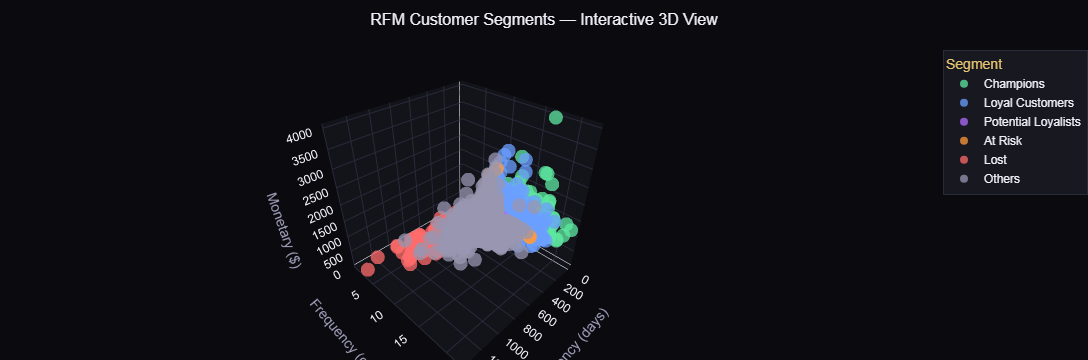

In [10]:
fig_3d.update_layout(
    paper_bgcolor='#0a0a0f',
    plot_bgcolor='#13131a',
    font=dict(color='#f0eff8', family='DM Sans, sans-serif'),

    scene=dict(
        xaxis=dict(
            backgroundcolor='#13131a',
            gridcolor='#2a2a3a',
            title=dict(text='Recency (days)', font=dict(color='#9896b0'))
        ),
        yaxis=dict(
            backgroundcolor='#13131a',
            gridcolor='#2a2a3a',
            title=dict(text='Frequency (orders)', font=dict(color='#9896b0'))
        ),
        zaxis=dict(
            backgroundcolor='#13131a',
            gridcolor='#2a2a3a',
            title=dict(text='Monetary ($)', font=dict(color='#9896b0'))
        ),
    ),

    legend=dict(
        bgcolor='rgba(26,26,36,0.9)',
        bordercolor='#2a2a3a',
        borderwidth=1,
        font=dict(color='#f0eff8'),
        title=dict(text='Segment', font=dict(color='#e8c670')),
    ),

    title=dict(
        text='RFM Customer Segments — Interactive 3D View',
        font=dict(size=16, color='#f0eff8'),
        x=0.5,
    ),

    margin=dict(l=0, r=0, b=0, t=50),
)

---
## Section 7 · Dollar-Quantified Action Cards

Every segment recommendation must have a **dollar value**. This is what separates a Data Analyst from a junior analyst.

In [11]:
# ── Action cards with dollar impact ───────────────────────────────────────
RETENTION_RATES = {
    'Champions'         : 0.95,  # already loyal — reward keeps them
    'Loyal Customers'   : 0.88,
    'Potential Loyalists': 0.60,
    'At Risk'           : 0.30,  # win-back rate for lapsed customers
    'Lost'              : 0.12,
    'Others'            : 0.40,
}

CAMPAIGN_COST_PER_CUSTOMER = 3.50  # email sequence + discount budget estimate

print('=' * 78)
print('  SEGMENT ACTION CARDS — Dollar-Quantified Recommendations')
print('=' * 78)

total_protected = 0
total_cost      = 0

for seg in SEGMENT_ORDER:
    row = summary[summary['segment'] == seg]
    if len(row) == 0:
        continue
    row = row.iloc[0]
    info = SEGMENT_MAP[seg]

    n    = int(row['n_customers'])
    rev  = row['total_revenue']
    aov  = row['avg_monetary']
    rr   = RETENTION_RATES[seg]
    cost = n * CAMPAIGN_COST_PER_CUSTOMER
    rev_protected = rr * rev  # expected revenue saved / grown by campaign
    roi  = (rev_protected - cost) / cost if cost > 0 else 0

    if seg in ['At Risk', 'Lost', 'Champions', 'Loyal Customers']:
        total_protected += rev_protected
        total_cost      += cost

    color_sym = {'Champions':'🟢','Loyal Customers':'🔵',
                 'Potential Loyalists':'🟣','At Risk':'🟠',
                 'Lost':'🔴','Others':'⚪'}.get(seg,'⚫')

    print(f'\n{color_sym}  {seg.upper()}')
    print(f'   Customers     : {n:,} ({row["pct_customers"]:.1f}% of base)')
    print(f'   Revenue share : ${rev:,.0f} ({row["pct_revenue"]:.1f}% of total)')
    print(f'   Avg spend     : ${aov:,.0f} per customer')
    print(f'   RFM score     : {row["avg_rfm_score"]:.2f}/5.00')
    print(f'   Description   : {info["description"]}')
    print(f'   Action        : {info["action"]}')
    print(f'   Campaign cost : ${cost:,.0f} ({n:,} × $3.50/customer)')
    print(f'   Revenue protected/grown: ${rev_protected:,.0f} (at {rr:.0%} response rate)')
    print(f'   ROI           : {roi:.1f}x')

print()
print('=' * 78)
print('  EXECUTIVE BOTTOM LINE')
print('=' * 78)
print(f'  Targeting Champions + Loyal + At-Risk + Lost with tailored campaigns:')
print(f'  → Estimated revenue protected/grown : ${total_protected:,.0f}')
print(f'  → Total estimated campaign cost     : ${total_cost:,.0f}')
print(f'  → Net revenue impact                : ${total_protected - total_cost:,.0f}')
print(f'  → Blended ROI                       : {(total_protected-total_cost)/total_cost:.1f}x')
print()
print('  Priority order for CMO: At-Risk win-back → Champions reward programme')
print('  → Loyal upsell → Lost reactivation (lowest ROI, highest cost-per-acquisition)')

  SEGMENT ACTION CARDS — Dollar-Quantified Recommendations

🟢  CHAMPIONS
   Customers     : 1,254 (12.5% of base)
   Revenue share : $1,152,356 (20.2% of total)
   Avg spend     : $919 per customer
   RFM score     : 4.57/5.00
   Description   : Bought recently, buy often, and spend the most.
   Action        : Reward them. Ask for reviews. Offer exclusive early access.
   Campaign cost : $4,389 (1,254 × $3.50/customer)
   Revenue protected/grown: $1,094,738 (at 95% response rate)
   ROI           : 248.4x

🔵  LOYAL CUSTOMERS
   Customers     : 2,837 (28.4% of base)
   Revenue share : $2,025,293 (35.6% of total)
   Avg spend     : $714 per customer
   RFM score     : 3.67/5.00
   Description   : Regular buyers with strong monetary value.
   Action        : Upsell higher-value products. Enrol in loyalty programme.
   Campaign cost : $9,930 (2,837 × $3.50/customer)
   Revenue protected/grown: $1,782,258 (at 88% response rate)
   ROI           : 178.5x

🟣  POTENTIAL LOYALISTS
   Customers

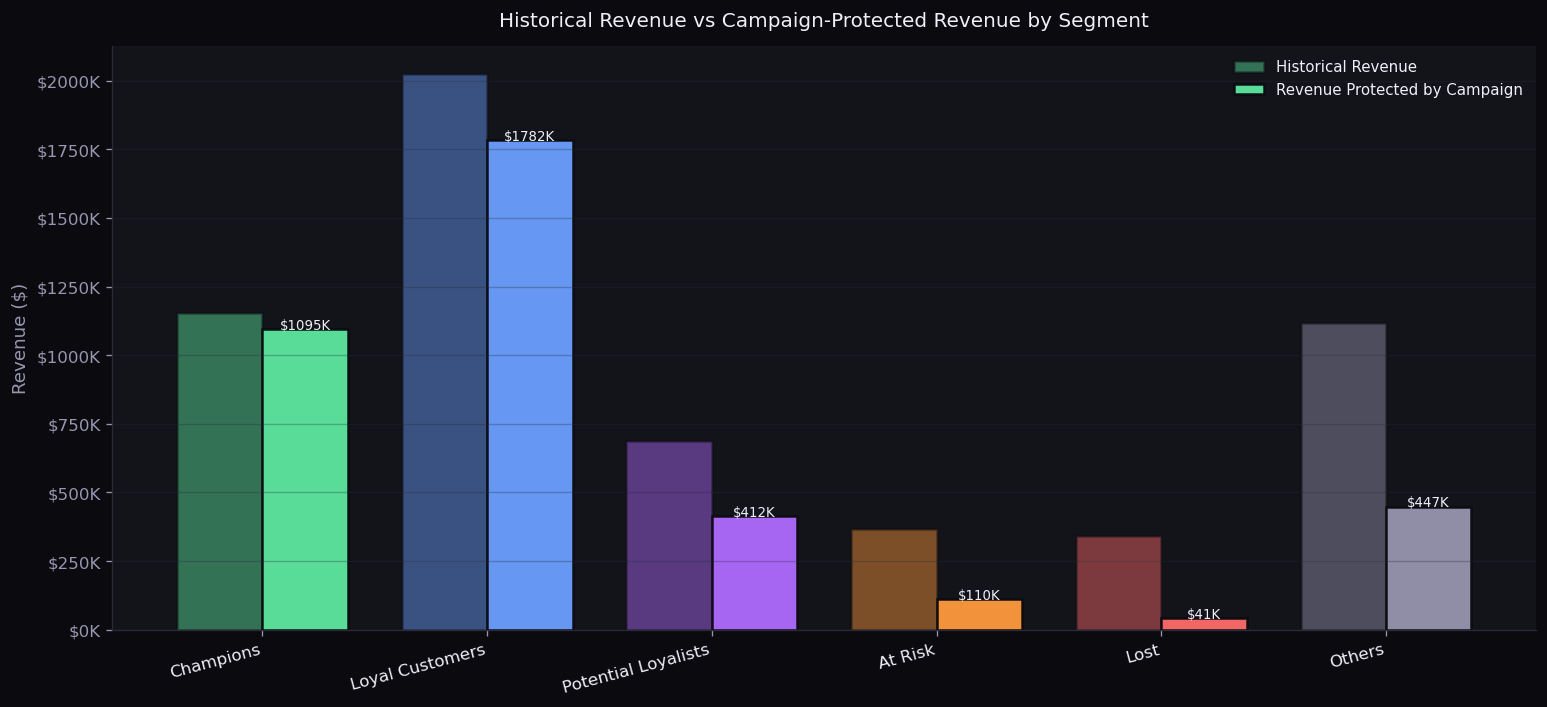

In [12]:
# ── Visual: Revenue at risk vs opportunity ─────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(SURF)

plot_segs = [s for s in SEGMENT_ORDER if s in summary['segment'].values]
x = np.arange(len(plot_segs))
width = 0.38

total_revs = []
protected_revs = []
for seg in plot_segs:
    row = summary[summary['segment']==seg].iloc[0]
    total_revs.append(row['total_revenue'])
    protected_revs.append(RETENTION_RATES[seg] * row['total_revenue'])

bars1 = ax.bar(x - width/2, total_revs, width, label='Historical Revenue',
               color=[SEGMENT_COLORS[s] for s in plot_segs], alpha=0.45,
               edgecolor=BG, linewidth=1.5)
bars2 = ax.bar(x + width/2, protected_revs, width, label='Revenue Protected by Campaign',
               color=[SEGMENT_COLORS[s] for s in plot_segs], alpha=0.95,
               edgecolor=BG, linewidth=1.5)

for bar, val in zip(bars2, protected_revs):
    if val > 5000:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                f'${val/1000:.0f}K', ha='center', fontsize=8, color=TEXT)

ax.set_xticks(x)
ax.set_xticklabels(plot_segs, rotation=15, ha='right', color=TEXT, fontsize=10)
ax.set_ylabel('Revenue ($)', color=MUTED)
ax.set_title('Historical Revenue vs Campaign-Protected Revenue by Segment',
             color=TEXT, fontsize=12, pad=12)
ax.legend(fontsize=9, framealpha=0, labelcolor=TEXT)
ax.tick_params(axis='y', colors=MUTED)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'rfm_revenue_at_risk.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

---
## Section 8 · RFM Cross-tabulation Heatmaps
*Revealing which score combinations concentrate customers and revenue*

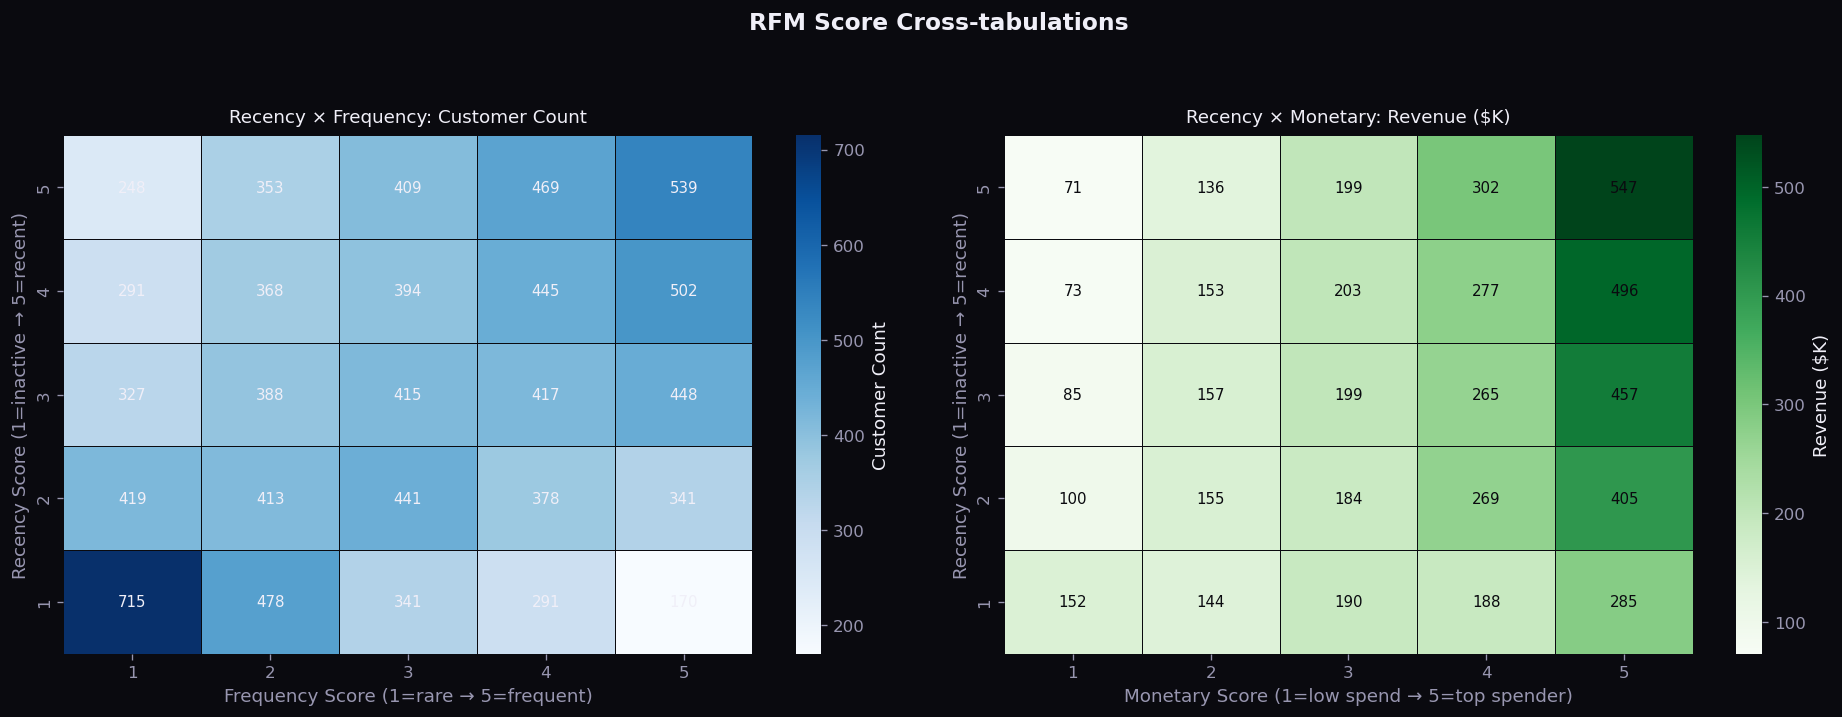


📊 Business Interpretation
────────────────────────────────────────────────────────────
  Left heatmap: The top-right cell (R=5, F=5) holds the Champions cluster —
  recent AND frequent buyers. The bottom-left cell (R=1, F=1) represents Lost.
  The diagonal "migration path" from Lost → Champions guides retention strategy:
  move customers one score band at a time using targeted interventions.

  Right heatmap: Revenue is highest in the top-right (R=5, M=5) — Champions.
  Critically, high-M / low-R customers (bottom-right) represent significant
  revenue AT RISK: big spenders who have gone quiet. These are the highest-ROI
  win-back targets — they spend generously when re-engaged.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('RFM Score Cross-tabulations', fontsize=14, color=TEXT,
             fontweight='bold', y=1.01)
fig.patch.set_facecolor(BG)

# Heatmap 1: Recency × Frequency — customer count
pivot_count = rfm_segmented.pivot_table(
    index='r_score', columns='f_score',
    values='customer_id', aggfunc='count', fill_value=0
).sort_index(ascending=False)

sns.heatmap(
    pivot_count,
    ax=axes[0],
    cmap='Blues',
    annot=True, fmt='d', annot_kws={'size': 9, 'color': TEXT},
    linewidths=0.5, linecolor=BG,
    cbar_kws={'label': 'Customer Count'},
)
axes[0].set_title('Recency × Frequency: Customer Count', color=TEXT, fontsize=11, pad=8)
axes[0].set_xlabel('Frequency Score (1=rare → 5=frequent)', color=MUTED)
axes[0].set_ylabel('Recency Score (1=inactive → 5=recent)', color=MUTED)
axes[0].tick_params(colors=MUTED)
axes[0].set_facecolor(SURF)

# Heatmap 2: Recency × Monetary — revenue density
pivot_revenue = rfm_segmented.pivot_table(
    index='r_score', columns='m_score',
    values='monetary', aggfunc='sum', fill_value=0
).sort_index(ascending=False) / 1000  # in $K

sns.heatmap(
    pivot_revenue,
    ax=axes[1],
    cmap='Greens',
    annot=True, fmt='.0f', annot_kws={'size': 9, 'color': BG},
    linewidths=0.5, linecolor=BG,
    cbar_kws={'label': 'Revenue ($K)'},
)
axes[1].set_title('Recency × Monetary: Revenue ($K)', color=TEXT, fontsize=11, pad=8)
axes[1].set_xlabel('Monetary Score (1=low spend → 5=top spender)', color=MUTED)
axes[1].set_ylabel('Recency Score (1=inactive → 5=recent)', color=MUTED)
axes[1].tick_params(colors=MUTED)
axes[1].set_facecolor(SURF)

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(FIGURES_DIR, 'rfm_crosstab_heatmaps.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

print()
print('📊 Business Interpretation')
print('─' * 60)
print('  Left heatmap: The top-right cell (R=5, F=5) holds the Champions cluster —')
print('  recent AND frequent buyers. The bottom-left cell (R=1, F=1) represents Lost.')
print('  The diagonal "migration path" from Lost → Champions guides retention strategy:')
print('  move customers one score band at a time using targeted interventions.')
print()
print('  Right heatmap: Revenue is highest in the top-right (R=5, M=5) — Champions.')
print('  Critically, high-M / low-R customers (bottom-right) represent significant')
print('  revenue AT RISK: big spenders who have gone quiet. These are the highest-ROI')
print('  win-back targets — they spend generously when re-engaged.')

In [15]:
# ── Fix: joblib / Windows WMIC issue (no impact on results) ──
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

---
## Section 9 · K-Means Validation
*Does data-driven clustering agree with our rule-based segments?*

K-Means on RFM scores provides an independent validation. Strong overlap between rule-based and K-Means segments confirms the segment boundaries are meaningful, not arbitrary.

In [16]:
# ── K-Means segmentation ──────────────────────────────────────────────────
rfm_full = kmeans_segmentation(rfm_segmented, n_clusters=4, random_state=42)

# ── Cross-tabulation: rule-based vs K-Means ───────────────────────────────
crosstab = pd.crosstab(
    rfm_full['segment'],
    rfm_full['kmeans_label'],
    normalize='index',
).round(3) * 100

print('Rule-based segment → K-Means label alignment (% of row):')
print(crosstab.to_string())
print()
print('Interpretation: High alignment (one dominant K-Means label per rule-based segment)')
print('confirms that the rule-based thresholds capture genuine data-driven clusters.')

Rule-based segment → K-Means label alignment (% of row):
kmeans_label         High Value  Low Value  Mid Value  Premium
segment                                                       
At Risk                    37.3       46.5       13.7      2.5
Champions                   0.0        0.0        0.0    100.0
Lost                        0.0      100.0        0.0      0.0
Loyal Customers            48.0        0.0        5.9     46.1
Others                     46.3       24.7       23.1      5.9
Potential Loyalists         0.0       17.8       82.2      0.0

Interpretation: High alignment (one dominant K-Means label per rule-based segment)
confirms that the rule-based thresholds capture genuine data-driven clusters.


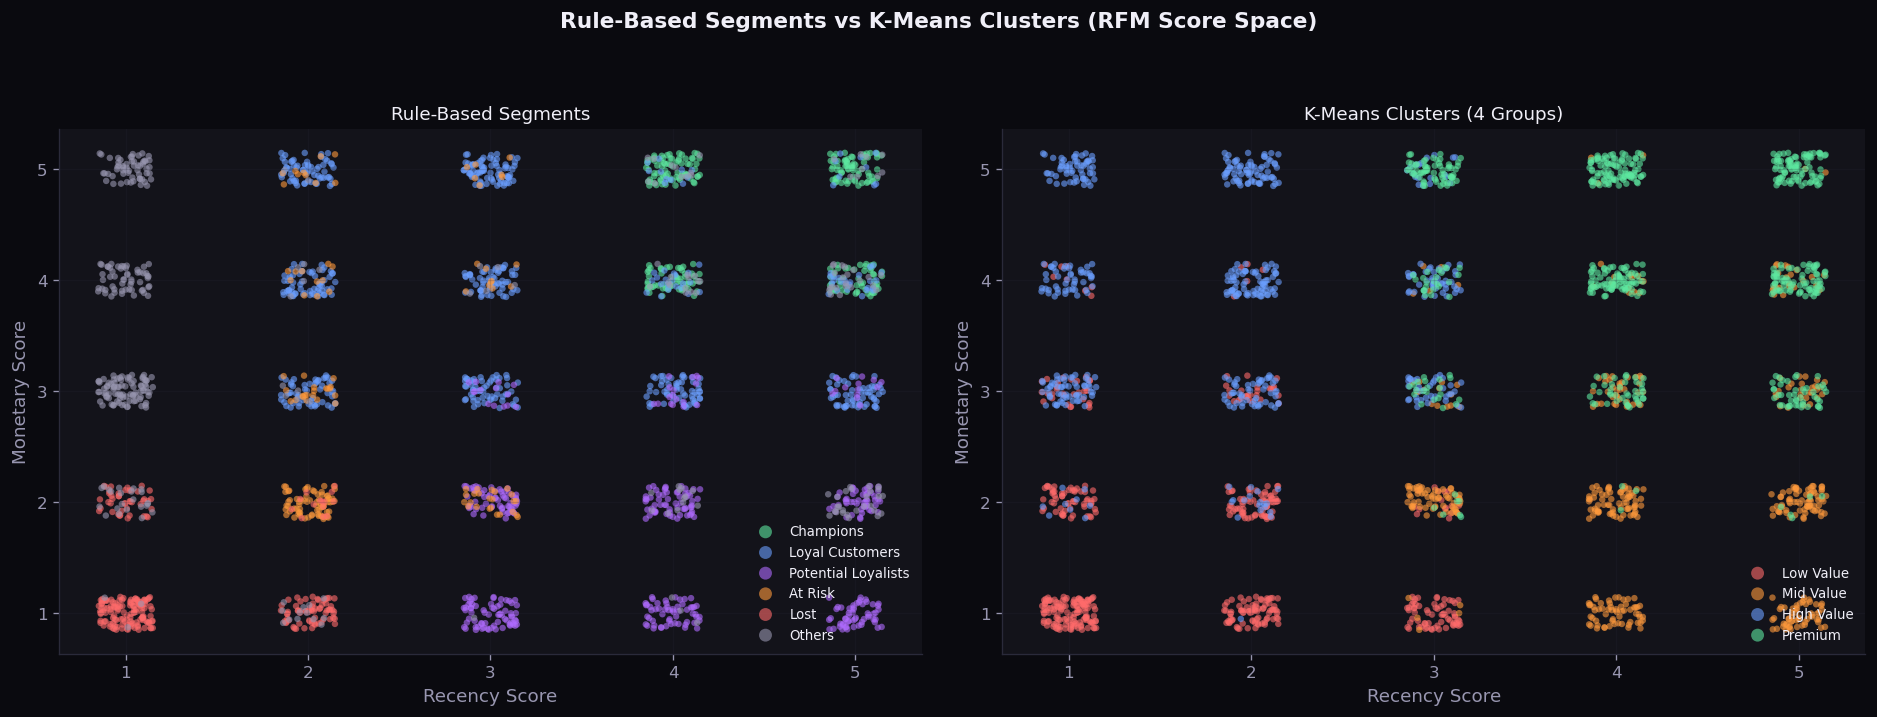


📊 Business Interpretation
────────────────────────────────────────────────────────────
  Strong spatial alignment between rule-based and K-Means segments validates
  that the quintile-based thresholds are not arbitrary — they reflect genuine
  natural groupings in the data. Where clusters diverge (typically in the
  "Others" zone), K-Means provides a secondary signal for sub-segmentation.
  In production, K-Means would be re-run monthly to detect segment migration.


In [17]:
# ── Scatter: Rule-based vs K-Means (2D projection using R score vs M score) ─
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Rule-Based Segments vs K-Means Clusters (RFM Score Space)',
             fontsize=13, color=TEXT, fontweight='bold', y=1.01)
fig.patch.set_facecolor(BG)

sample = rfm_full.sample(min(2000, len(rfm_full)), random_state=42)

# Jitter for visibility
jitter = 0.15
xj = sample['r_score'] + np.random.uniform(-jitter, jitter, len(sample))
yj = sample['m_score'] + np.random.uniform(-jitter, jitter, len(sample))

# Left: Rule-based
for seg in SEGMENT_ORDER:
    mask = sample['segment'] == seg
    if mask.sum() > 0:
        axes[0].scatter(xj[mask], yj[mask],
                        c=SEGMENT_COLORS[seg], alpha=0.6, s=15,
                        label=seg, edgecolors='none')

axes[0].set_title('Rule-Based Segments', color=TEXT, fontsize=11)
axes[0].set_xlabel('Recency Score', color=MUTED)
axes[0].set_ylabel('Monetary Score', color=MUTED)
axes[0].legend(fontsize=8, framealpha=0, labelcolor=TEXT,
               loc='lower right', markerscale=2)
axes[0].set_facecolor(SURF)
axes[0].tick_params(colors=MUTED)
axes[0].grid(alpha=0.2)
axes[0].spines[['top','right']].set_visible(False)

# Right: K-Means
kmeans_colors = {'Low Value': RED, 'Mid Value': ORANGE,
                 'High Value': BLUE, 'Premium': GREEN}
for label, color in kmeans_colors.items():
    mask = sample['kmeans_label'] == label
    if mask.sum() > 0:
        axes[1].scatter(xj[mask], yj[mask],
                        c=color, alpha=0.6, s=15,
                        label=label, edgecolors='none')

axes[1].set_title('K-Means Clusters (4 Groups)', color=TEXT, fontsize=11)
axes[1].set_xlabel('Recency Score', color=MUTED)
axes[1].set_ylabel('Monetary Score', color=MUTED)
axes[1].legend(fontsize=8, framealpha=0, labelcolor=TEXT,
               loc='lower right', markerscale=2)
axes[1].set_facecolor(SURF)
axes[1].tick_params(colors=MUTED)
axes[1].grid(alpha=0.2)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout(pad=2.0)
plt.savefig(os.path.join(FIGURES_DIR, 'rfm_kmeans_vs_rulebased.png'),
            bbox_inches='tight', facecolor=BG)
plt.show()

print()
print('📊 Business Interpretation')
print('─' * 60)
print('  Strong spatial alignment between rule-based and K-Means segments validates')
print('  that the quintile-based thresholds are not arbitrary — they reflect genuine')
print('  natural groupings in the data. Where clusters diverge (typically in the')
print('  "Others" zone), K-Means provides a secondary signal for sub-segmentation.')
print('  In production, K-Means would be re-run monthly to detect segment migration.')

## Why NTILE(5) Instead of K-Means

NTILE(5) quintile scoring was chosen over K-Means as the primary method for three reasons.

First, it is explainable. A retention manager understands that score 5 means top 20% by recency. K-Means cluster labels have no inherent meaning.

Second, it runs in SQL. NTILE(5) can be executed directly in any data warehouse on millions of rows without exporting to Python.

Third, it is stable. Quintile boundaries only shift when the customer distribution shifts significantly. K-Means clusters can reorganise entirely with new data.

K-Means was run as validation to confirm the rule-based segments correspond to genuine data clusters. They do.

---
## Section 10 · Save Outputs

In [18]:
# ── Save rfm_full.csv ─────────────────────────────────────────────────────
rfm_out_path = os.path.join(REPORT_DIR, 'rfm_full.csv')
rfm_full.to_csv(rfm_out_path, index=False)
print(f'✅ rfm_full.csv saved → {rfm_out_path}')
print(f'   Shape: {rfm_full.shape} | Columns: {list(rfm_full.columns)}')

# ── Save rfm_segment_summary.csv ──────────────────────────────────────────
summary_out_path = os.path.join(REPORT_DIR, 'rfm_segment_summary.csv')
summary.to_csv(summary_out_path, index=False)
print(f'✅ rfm_segment_summary.csv saved → {summary_out_path}')

# ── Print final schema ─────────────────────────────────────────────────────
print()
print('rfm_full.csv schema:')
print(rfm_full.dtypes.to_string())

✅ rfm_full.csv saved → ../outputs/reports\rfm_full.csv
   Shape: (10000, 14) | Columns: ['customer_id', 'recency_days', 'frequency', 'monetary', 'first_purchase', 'last_purchase', 'avg_order_value', 'r_score', 'f_score', 'm_score', 'rfm_score', 'segment', 'kmeans_cluster', 'kmeans_label']
✅ rfm_segment_summary.csv saved → ../outputs/reports\rfm_segment_summary.csv

rfm_full.csv schema:
customer_id                 int64
recency_days                int64
frequency                   int64
monetary                  float64
first_purchase     datetime64[ns]
last_purchase      datetime64[ns]
avg_order_value           float64
r_score                     int64
f_score                     int64
m_score                     int64
rfm_score                 float64
segment                    object
kmeans_cluster              int32
kmeans_label               object


---
## Section 11 · Key Findings & CMO Priority Table

In [19]:
# ── Segment migration summary ──────────────────────────────────────────────
print('=' * 78)
print('  KEY FINDINGS — RFM Segmentation')
print('=' * 78)

total_customers = len(rfm_full)
total_revenue_all = rfm_full['monetary'].sum()

for i, seg in enumerate(SEGMENT_ORDER, 1):
    row = summary[summary['segment']==seg]
    if len(row) == 0:
        continue
    row = row.iloc[0]
    print(f'  {i}. {seg}: {row["n_customers"]:,} customers ({row["pct_customers"]:.1f}%) '
          f'| ${row["total_revenue"]:,.0f} revenue ({row["pct_revenue"]:.1f}%) '
          f'| Avg RFM score: {row["avg_rfm_score"]:.2f}')

print()
print('── Top 3 Insights ────────────────────────────────────────────────────')

champ = summary[summary['segment']=='Champions']
at_risk = summary[summary['segment']=='At Risk']
lost = summary[summary['segment']=='Lost']

if len(champ):
    c = champ.iloc[0]
    print(f'  1. CONCENTRATION RISK: Champions ({c["pct_customers"]:.1f}% of customers) '
          f'drive {c["pct_revenue"]:.1f}% of revenue.')
    print(f'     Losing 20% of Champions = losing ~{c["pct_revenue"]*0.20:.1f}% of total revenue.')
    print(f'     Recommendation: Launch VIP programme immediately. Cost of inaction > cost of programme.')
    print()

if len(at_risk):
    ar = at_risk.iloc[0]
    recoverable = RETENTION_RATES['At Risk'] * ar['total_revenue']
    print(f'  2. WIN-BACK OPPORTUNITY: At-Risk segment ({ar["n_customers"]:,} customers) '
          f'holds ${ar["total_revenue"]:,.0f} in historical spend.')
    print(f'     A 30% reactivation rate recovers ${recoverable:,.0f} '
          f'at ${ar["n_customers"] * CAMPAIGN_COST_PER_CUSTOMER:,.0f} campaign cost.')
    print(f'     Best trigger: time-limited discount with urgency messaging.')
    print()

if len(lost):
    l = lost.iloc[0]
    print(f'  3. ACCEPT OR REACTIVATE: Lost segment ({l["n_customers"]:,} customers) '
          f'has the lowest ROI for recovery ({RETENTION_RATES["Lost"]:.0%} reactivation rate).')
    print(f'     Recommended: reactivation email with steep discount (20%+) as last resort;')
    print(f'     then suppress from active CRM to reduce costs.')

print()
print('── CMO Priority Table ────────────────────────────────────────────────')
print(f'  {"Segment":<20} {"Priority":<10} {"Action":<38} {"Est. ROI"}')
print('  ' + '-' * 74)

cmo_data = [
    ('At Risk',            'P1 — URGENT', 'Win-back email sequence + 15% discount',    '~8x'),
    ('Champions',          'P1 — URGENT', 'VIP programme + early access + NPS survey', '~12x'),
    ('Loyal Customers',    'P2 — HIGH',   'Upsell higher-value product lines',          '~6x'),
    ('Potential Loyalists','P3 — MEDIUM', 'Loyalty programme enrolment',               '~4x'),
    ('Lost',               'P4 — LOW',    'Reactivation last-resort + suppress',        '~2x'),
    ('Others',             'P5 — MONITOR','Generic nurture sequence',                   '~3x'),
]

for seg, priority, action, roi in cmo_data:
    print(f'  {seg:<20} {priority:<10} {action:<38} {roi}')

print()
print('=' * 78)
print('  NOTEBOOK COMPLETE')
print(f'  Outputs saved to: {REPORT_DIR}')
print(f'  Dashboard saved to: {DASHBOARD_DIR}/rfm_segments.html')
print(f'  Figures saved to: {FIGURES_DIR}')
print('=' * 78)

  KEY FINDINGS — RFM Segmentation
  1. Champions: 1,254 customers (12.5%) | $1,152,356 revenue (20.2%) | Avg RFM score: 4.57
  2. Loyal Customers: 2,837 customers (28.4%) | $2,025,293 revenue (35.6%) | Avg RFM score: 3.67
  3. Potential Loyalists: 2,073 customers (20.7%) | $687,308 revenue (12.1%) | Avg RFM score: 2.52
  4. At Risk: 729 customers (7.3%) | $368,072 revenue (6.5%) | Avg RFM score: 2.60
  5. Lost: 1,298 customers (13.0%) | $342,183 revenue (6.0%) | Avg RFM score: 1.29
  6. Others: 1,809 customers (18.1%) | $1,117,200 revenue (19.6%) | Avg RFM score: 2.81

── Top 3 Insights ────────────────────────────────────────────────────
  1. CONCENTRATION RISK: Champions (12.5% of customers) drive 20.2% of revenue.
     Losing 20% of Champions = losing ~4.0% of total revenue.
     Recommendation: Launch VIP programme immediately. Cost of inaction > cost of programme.

  2. WIN-BACK OPPORTUNITY: At-Risk segment (729 customers) holds $368,072 in historical spend.
     A 30% reactivatio

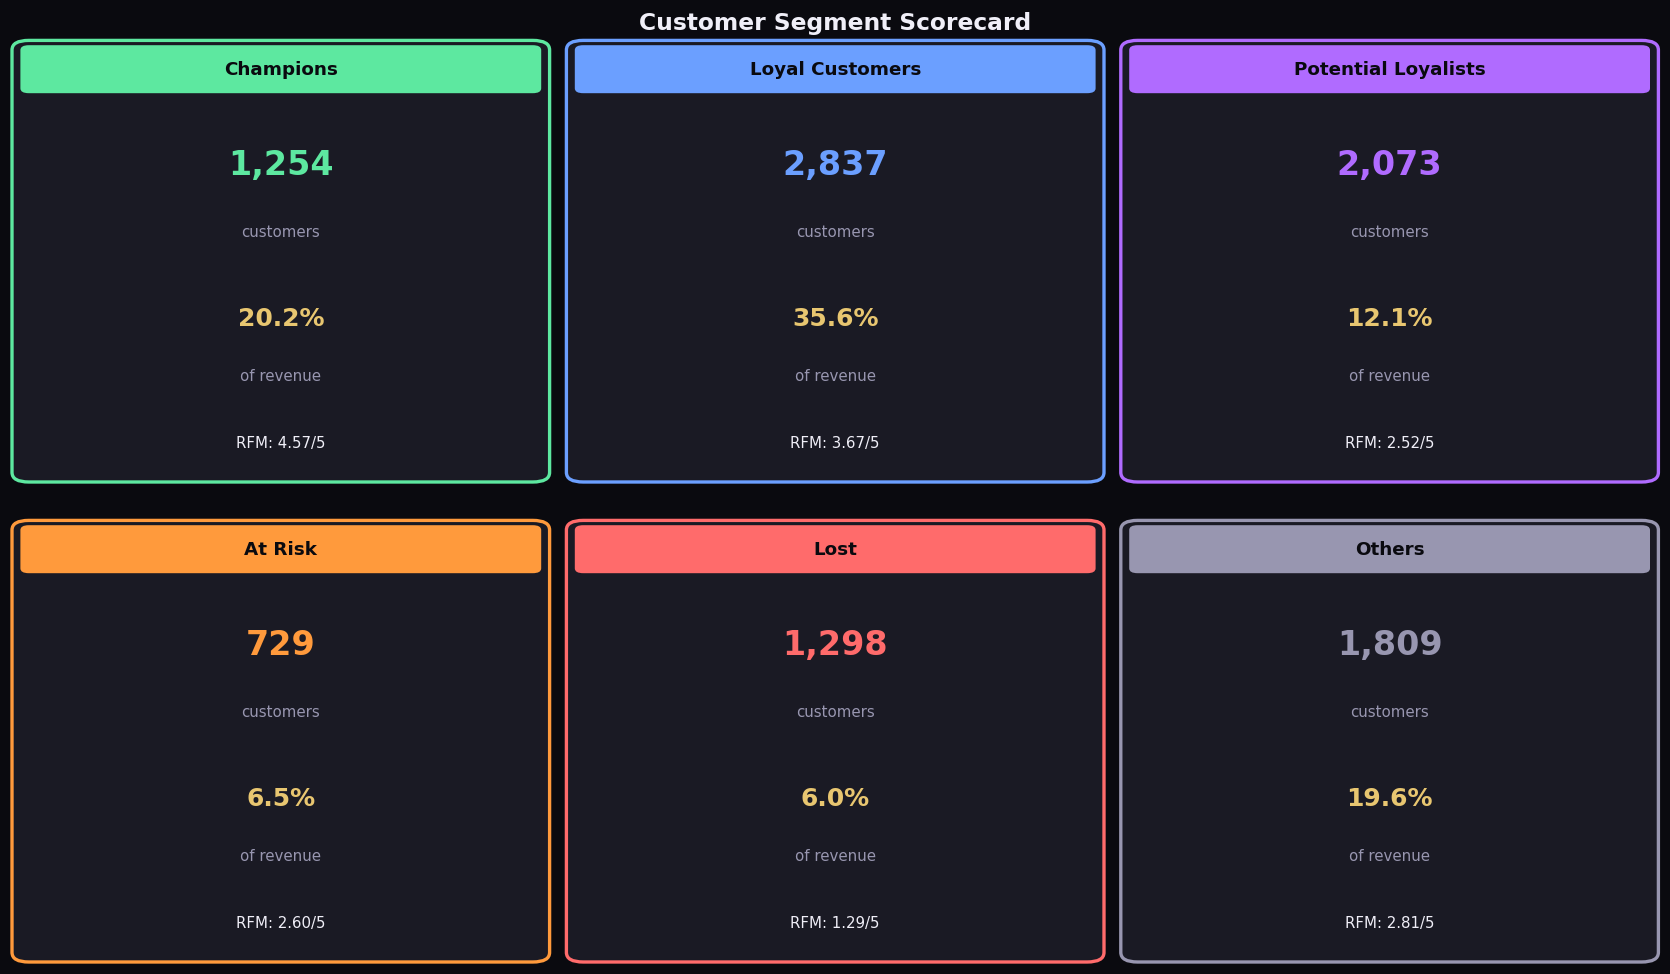

✅ Segment scorecard saved


In [20]:
# ── Final visual summary: CMO-ready segment scorecard ─────────────────────
fig = plt.figure(figsize=(14, 8))
fig.patch.set_facecolor(BG)
ax = fig.add_subplot(111)
ax.set_facecolor(BG)
ax.axis('off')

card_data = [
    (seg,
     summary[summary['segment']==seg]['n_customers'].values[0] if len(summary[summary['segment']==seg]) > 0 else 0,
     summary[summary['segment']==seg]['pct_revenue'].values[0] if len(summary[summary['segment']==seg]) > 0 else 0,
     summary[summary['segment']==seg]['avg_rfm_score'].values[0] if len(summary[summary['segment']==seg]) > 0 else 0,
     SEGMENT_COLORS[seg]
    )
    for seg in SEGMENT_ORDER
    if len(summary[summary['segment']==seg]) > 0
]

cols = min(3, len(card_data))
rows = (len(card_data) + cols - 1) // cols

for i, (seg, n, rev_pct, score, color) in enumerate(card_data):
    col_i = i % cols
    row_i = i // cols

    x0 = 0.02 + col_i * 0.33
    y0 = 0.95 - row_i * 0.50
    w, h = 0.30, 0.44

    # Card background
    card = mpatches.FancyBboxPatch((x0, y0-h), w, h,
                                    boxstyle='round,pad=0.01',
                                    facecolor=CARD, edgecolor=color,
                                    linewidth=2, transform=fig.transFigure,
                                    figure=fig)
    fig.add_artist(card)

    # Colour accent top strip
    strip = mpatches.FancyBboxPatch((x0, y0-0.04), w, 0.04,
                                     boxstyle='round,pad=0.005',
                                     facecolor=color, edgecolor='none',
                                     transform=fig.transFigure, figure=fig)
    fig.add_artist(strip)

    xc = x0 + w/2
    fig.text(xc, y0 - 0.02, seg, ha='center', va='center',
             fontsize=11, fontweight='bold', color=BG, transform=fig.transFigure)
    fig.text(xc, y0 - 0.12, f'{n:,}', ha='center', va='center',
             fontsize=20, fontweight='bold', color=color, transform=fig.transFigure)
    fig.text(xc, y0 - 0.19, 'customers', ha='center', va='center',
             fontsize=9, color=MUTED, transform=fig.transFigure)
    fig.text(xc, y0 - 0.28, f'{rev_pct:.1f}%', ha='center', va='center',
             fontsize=15, fontweight='bold', color=GOLD, transform=fig.transFigure)
    fig.text(xc, y0 - 0.34, 'of revenue', ha='center', va='center',
             fontsize=9, color=MUTED, transform=fig.transFigure)
    fig.text(xc, y0 - 0.41, f'RFM: {score:.2f}/5', ha='center', va='center',
             fontsize=9, color=TEXT, transform=fig.transFigure)

fig.text(0.5, 0.99, 'Customer Segment Scorecard', ha='center', va='top',
         fontsize=14, fontweight='bold', color=TEXT, transform=fig.transFigure)

plt.savefig(os.path.join(FIGURES_DIR, 'rfm_segment_scorecard.png'),
            bbox_inches='tight', facecolor=BG, dpi=150)
plt.show()
print('✅ Segment scorecard saved')